In [1]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hvplot.pandas
import cdk.logging
import logging

log = cdk.logging.setup_logging(log_level=logging.INFO)
pr.plot_setup()

[11/04/24 23:14:59] INFO     Logging initialized                  __init__.py:26


In [2]:
pr.plot_setup()

Load data

In [3]:
data, platemap = pr.load_platereader_data("../../tests/test_data/cytation_dna_sweep.txt", "../../tests/test_data/platemap.csv")
data.head()


,Well,Row,Column,Time,Seconds,Temperature (C),Read,Data,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,B,1,0 days 00:00:00,0.00,37.00,"490,520",289.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
1,B1,B,1,0 days 00:05:00,300.00,37.00,"490,520",312.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
2,B1,B,1,0 days 00:10:00,600.00,37.00,"490,520",449.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
3,B1,B,1,0 days 00:15:00,900.00,37.00,"490,520",982.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
4,B1,B,1,0 days 00:20:00,1200.00,37.00,"490,520",1880.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00


# Basic Plots

Look at a plot of plate reader data, laid out the same as the plate.

[11/04/24 18:04:18] DEBUG    Loaded backend                        pyplot.py:487
                             module://matplotlib_inline.backend_in              
                             line version unknown.                              
                    DEBUG    Loaded backend                        pyplot.py:487
                             module://matplotlib_inline.backend_in              
                             line version unknown.                              
                    DEBUG    findfont: Matching             font_manager.py:1416
                             sans\-serif:style=normal:varia                     
                             nt=normal:weight=normal:stretc                     
                             h=normal:size=10.0.                                
                    DEBUG    findfont:                      font_manager.py:1428
                             score(FontEntry(fname='/Users/                     
                            

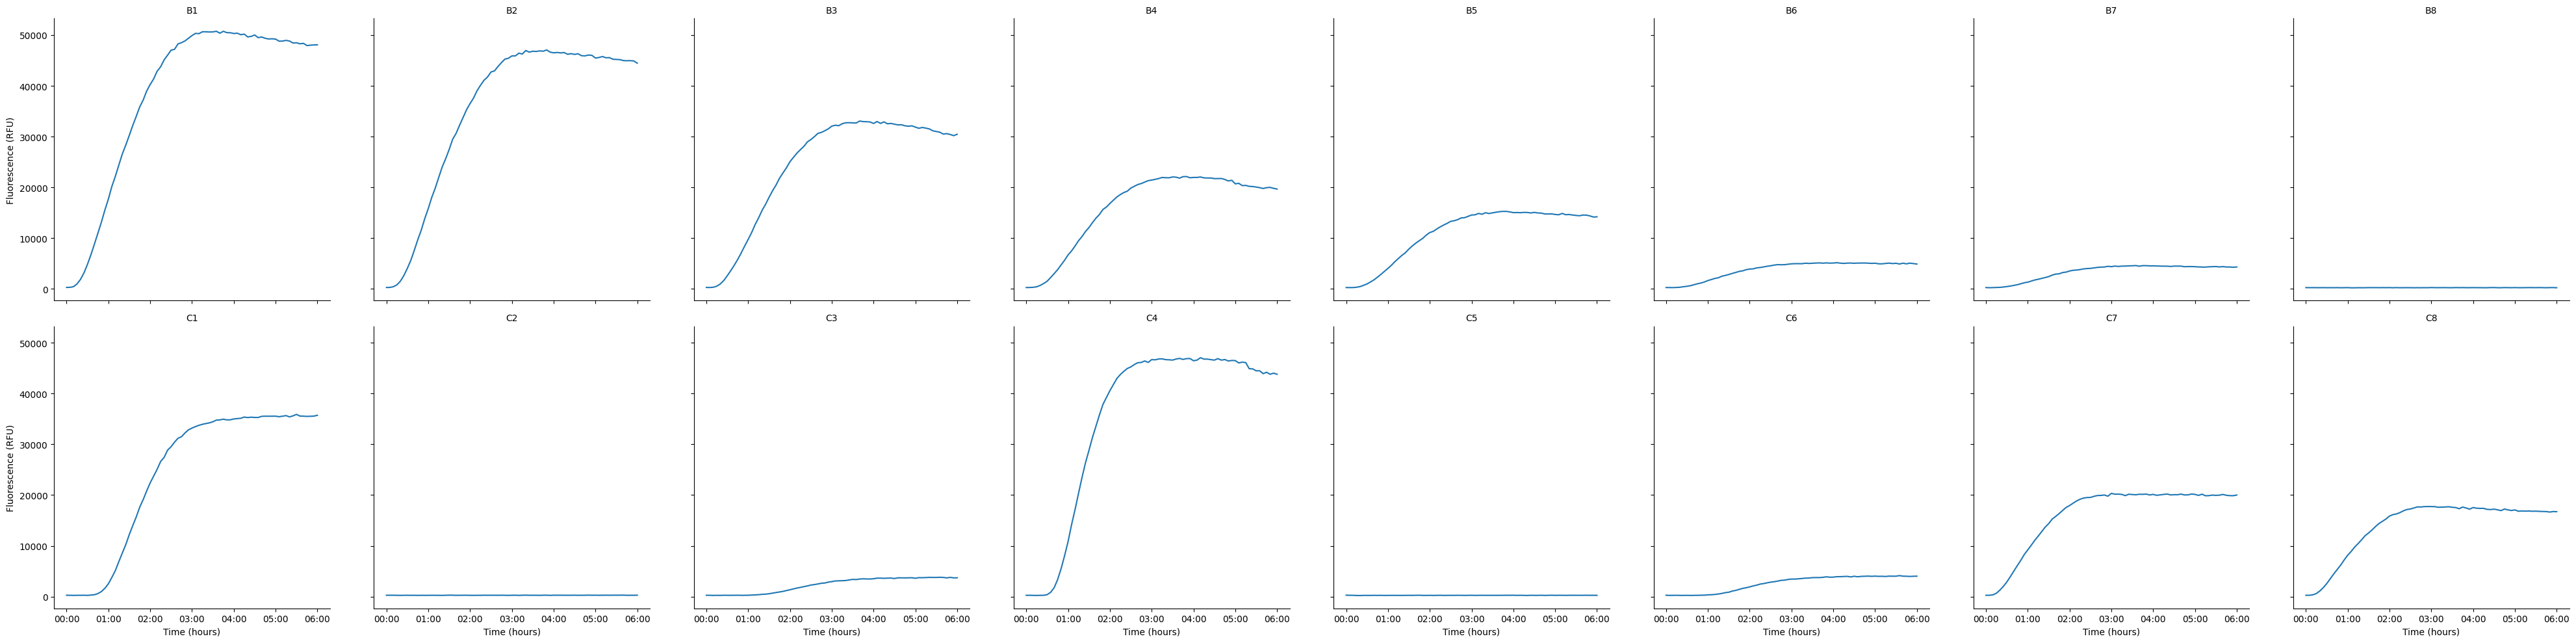

In [3]:
pr.plot_plate(data)

## Time-series Traces

Plot all curves, with one plot per experiment.

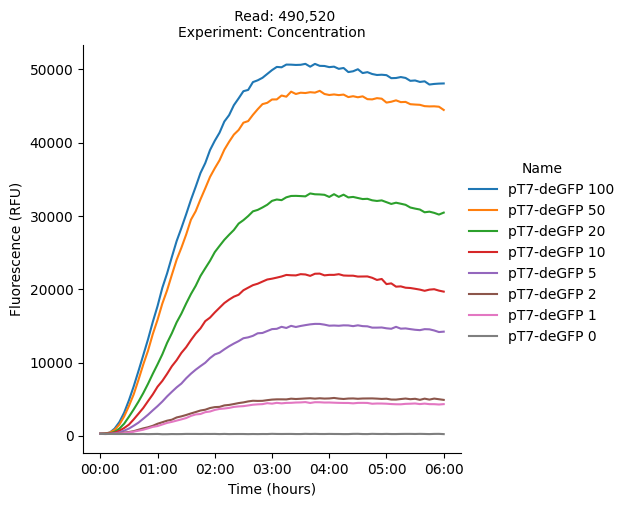

In [4]:
import cdk.analysis.cytosol.platereader as pr

data = pr.load_platereader_data("../../tests/test_data/cytation_dna_sweep.txt", "../../tests/test_data/platemap.csv")[0]
pr.plot_curves_by_name(data[data["Experiment"] == "Concentration"])

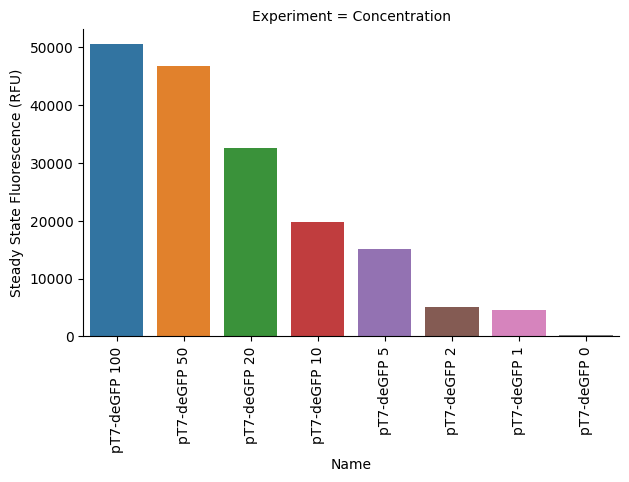

In [8]:
pr.plot_steadystate(data[data["Experiment"] == "Concentration"], hue="Name", native_scale=False)

[11/04/24 18:05:00] DEBUG    var_len=10                       platereader.py:426


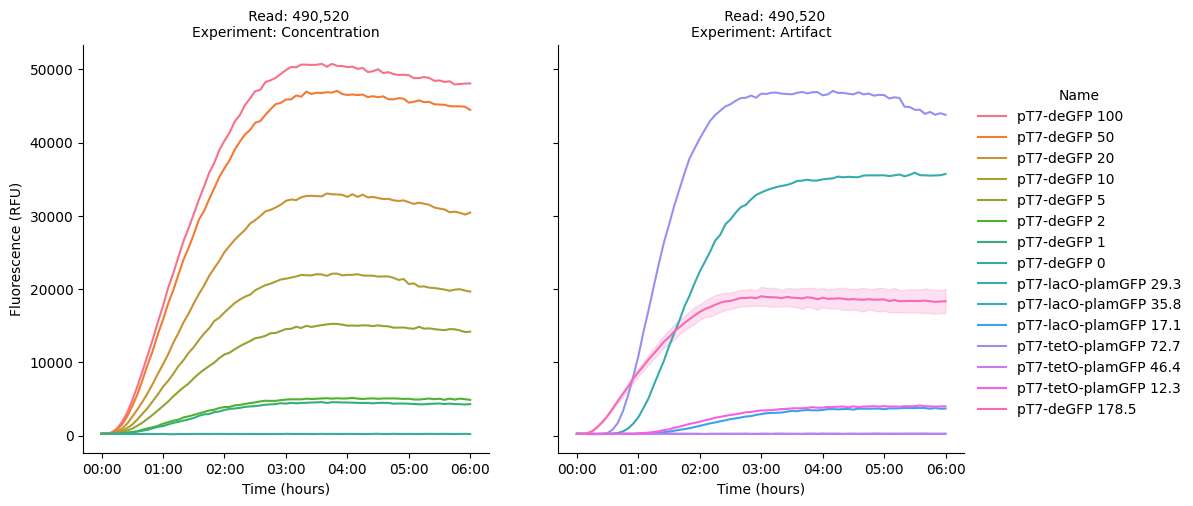

In [5]:
pr.plot_curves_by_name(data=data)

Plot curves with control over how the data is separated.

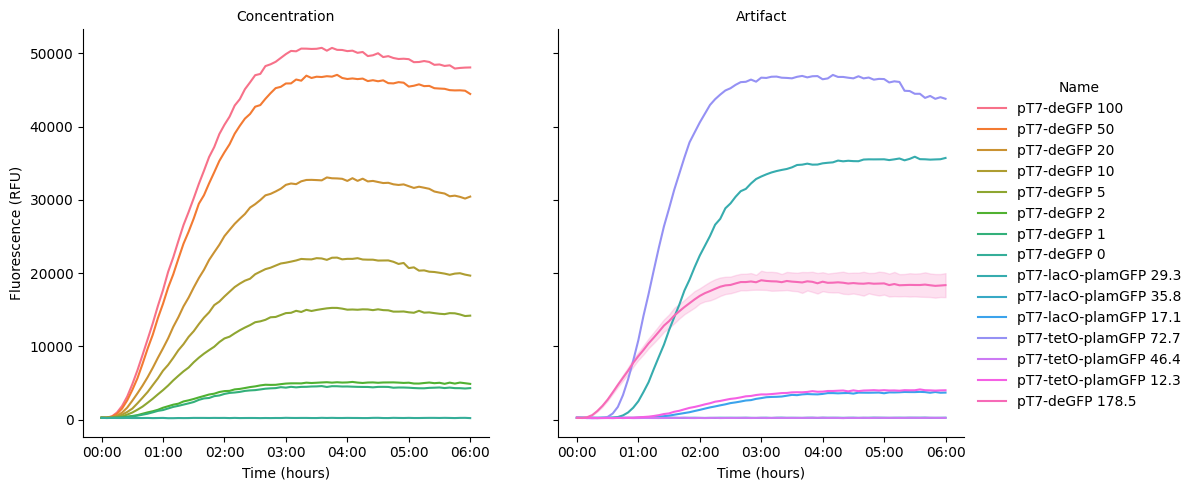

In [93]:
pr.plot_curves(data, hue="Name", col="Experiment")

In [96]:
platemap

,Well,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
1,B2,Concentration,pT7-deGFP 50,pT7-deGFP (AR-11),50.00
2,B3,Concentration,pT7-deGFP 20,pT7-deGFP (AR-11),20.00
3,B4,Concentration,pT7-deGFP 10,pT7-deGFP (AR-11),10.00
4,B5,Concentration,pT7-deGFP 5,pT7-deGFP (AR-11),5.00
5,B6,Concentration,pT7-deGFP 2,pT7-deGFP (AR-11),2.00
6,B7,Concentration,pT7-deGFP 1,pT7-deGFP (AR-11),1.00
7,B8,Concentration,pT7-deGFP 0,pT7-deGFP (AR-11),0.00
8,C1,Artifact,pT7-lacO-plamGFP 29.3,pT7-lacO-plamGFP (20240622),29.30
9,C2,Artifact,pT7-lacO-plamGFP 35.8,pT7-lacO-plamGFP (20240626),35.80


## Steady State

Plot steady state fluorescence based on our steady state definition. There are three potential ways to calculate steady state:
1. Steady state determined by the point of minimum change (i.e., where velocity is closest to zero). This is what we do by default.
2. Steady state determined by the maximum fluorescence value. This is the simplest to explain and understand.
3. Steady state as calculated by the intercept of the $V_{max}$ line with the maximum data value. This tends to match our intuition about where the steady state is the least, but has pleasing symmetry with the way we calculate the lag time (intercept of $V_{max}$ with zero).
    

In [88]:
pr.find_steady_state(data)

,,Time_steadystate,Data_steadystate
Well,Read,,
B1,"490,520",0 days 03:30:00,50621.00
B2,"490,520",0 days 03:45:00,46821.00
B3,"490,520",0 days 04:25:00,32592.00
B4,"490,520",0 days 05:55:00,19808.00
B5,"490,520",0 days 04:30:00,15073.00
B6,"490,520",0 days 04:10:00,5075.00
B7,"490,520",0 days 03:20:00,4498.00
B8,"490,520",0 days 03:20:00,253.00
C1,"490,520",0 days 05:10:00,35535.00


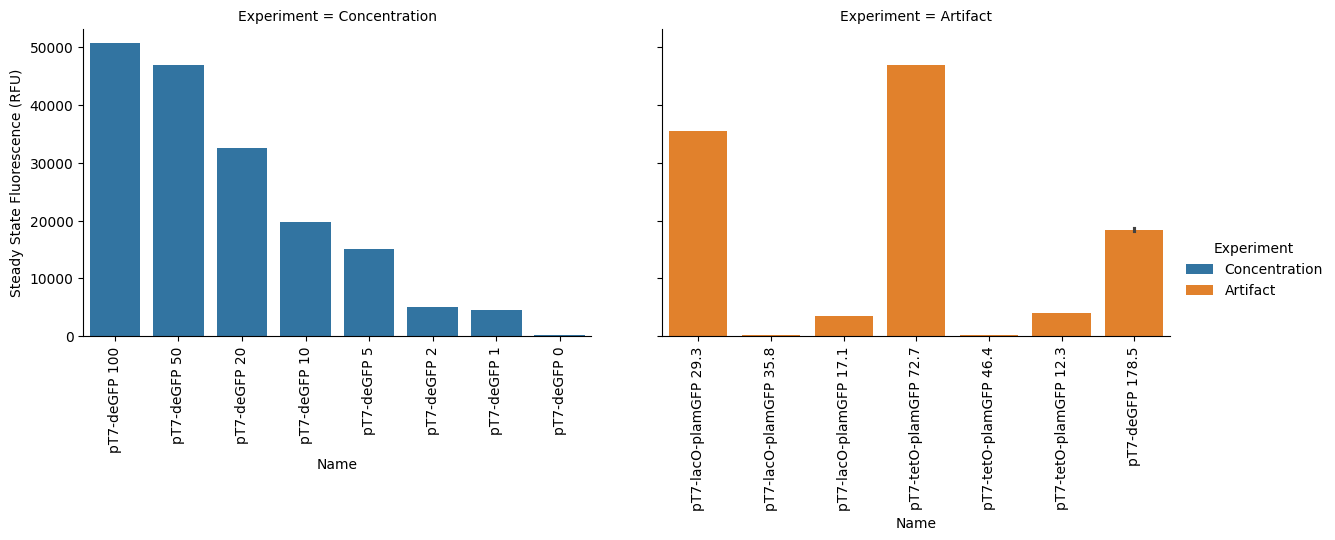

In [65]:
pr.plot_steadystate(data)

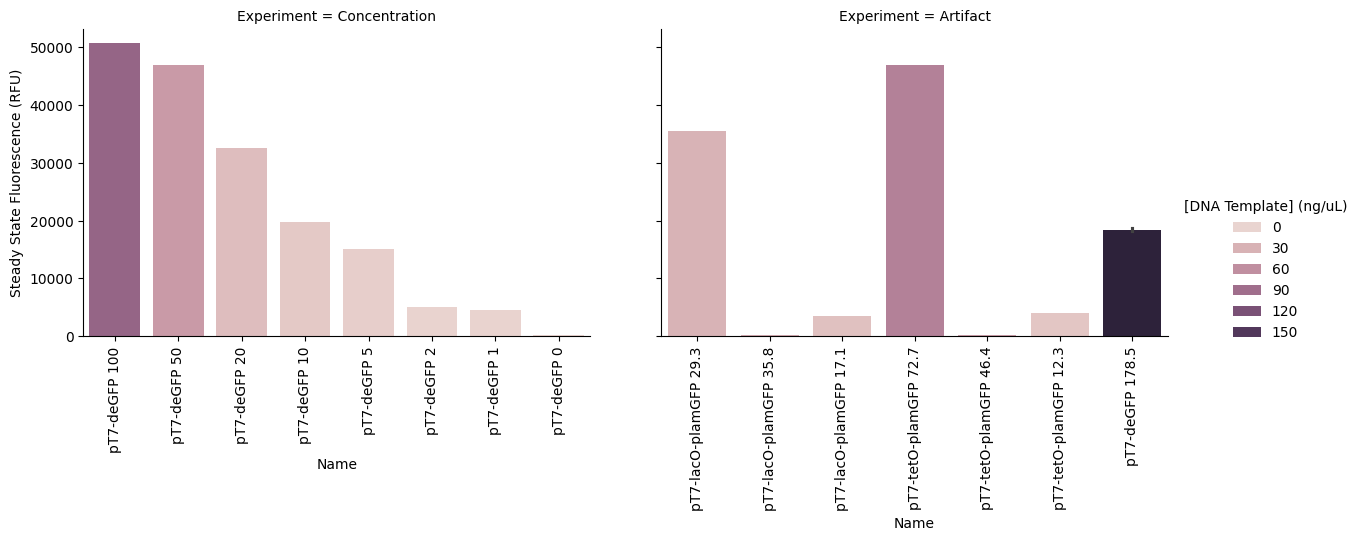

In [75]:
pr.plot_steadystate(data, hue="[DNA Template] (ng/uL)")

*add scatter?*

# Kinetics

Determine Kinetic Parameters

If kinetics can't be solved for a given well, a warning will be printed and that well will have "Not a Number" (NaN) or "Not a Time" (NaT) for the relevant parameters.

In [4]:
kinetics = pr.kinetic_analysis(data)
kinetics

[11/04/24 23:15:07] WARNING  Failed to solve: Optimal         platereader.py:505
                             parameters not found: Number of                    
                             calls to function has reached                      
                             maxfev = 800.                                      
                    WARNING  Failed to solve: Optimal         platereader.py:505
                             parameters not found: Number of                    
                             calls to function has reached                      
                             maxfev = 800.                                      


Velocity                                      Lag          \
                        Time     Data   Max                      Time    Data   
Well Read                                                                       
B1   490,520 0 days 01:05:00 20189.00  8.28 0 days 00:24:22.696177062 5339.74   
B2   490,520 0 days 00:55:00 13878.00  7.56 0 days 00:24:23.475959418 4818.95   
B3   490,520 0 days 01:10:00 12679.00  5.22 0 days 00:29:31.072796935 3579.02   
B4   490,520 0 days 01:00:00  6700.00  3.50 0 days 00:28:05.714285714 2071.91   
B5   490,520 0 days 01:30:00  7850.00  2.40 0 days 00:35:33.703190014 1864.95   
B6   490,520 0 days 01:20:00  2502.00  1.02 0 days 00:38:59.016393443  872.68   
B7   490,520 0 days 01:35:00  2718.00  0.98 0 days 00:48:46.530612245    0.00   
B8   490,520 0 days 03:00:00   268.00  0.09 0 days 02:12:08.571428571    0.00   
C1   490,520 0 days 01:30:00 12223.00  6.60 0 days 00:59:08.965169107 3770.87   
C2   490,520             NaT      NaN   NaN                       NaT     NaN   
C3   490,520 0 days 02:05:00  1524.00  0.57 0 days 01:20:41.860465116  523.35   
C4   490,520 0 days 01:05:00 14167.00 11.06 0 days 00:43:38.691588785 4762.91   
C5   490,520             NaT      NaN   NaN                       NaT     NaN   
C6   490,520 0 days 01:35:00  1093.00  0.74 0 days 01:10:22.972972973  562.43   
C7   490,520 0 days 00:55:00  8308.00  3.84 0 days 00:18:54.578627281 2148.57   
C8   490,520 0 days 00:55:00  7234.00  3.37 0 days 00:19:11.287128713 1848.80   

                Steady State               Fit               
                        Time     Data        L    k      x0  
Well Read                                                    
B1   490,520 0 days 03:30:00 50621.00 50290.12 0.00 4778.93  
B2   490,520 0 days 03:45:00 46821.00 46486.67 0.00 4884.37  
B3   490,520 0 days 04:25:00 32592.00 32753.46 0.00 5162.19  
B4   490,520 0 days 05:55:00 19808.00 21291.85 0.00 4989.96  
B5   490,520 0 days 04:30:00 15073.00 15073.09 0.00 5411.88  
B6   490,520 0 days 04:10:00  5075.00  5093.57 0.00 5063.40  
B7   490,520 0 days 03:20:00  4498.00     0.00 0.00    0.00  
B8   490,520 0 days 03:20:00   253.00     0.00 0.00    0.00  
C1   490,520 0 days 05:10:00 35535.00 35013.27 0.00 6447.70  
C2   490,520             NaT      NaN      NaN  NaN     NaN  
C3   490,520 0 days 03:55:00  3464.00  3673.27 0.00 8207.27  
C4   490,520 0 days 03:55:00 46897.00 46427.49 0.00 4904.73  
C5   490,520             NaT      NaN      NaN  NaN     NaN  
C6   490,520 0 days 04:45:00  4008.00  3949.34 0.00 7376.26  
C7   490,520 0 days 04:25:00 20034.00 20073.07 0.00 4012.84  
C8   490,520 0 days 05:30:00 16839.00 17333.19 0.00 3952.78

Plot Kinetics

[11/04/24 23:15:10] INFO     Kinetics information not         platereader.py:622
                             available for C2.                                  
                    INFO     Kinetics information not         platereader.py:622
                             available for C5.                                  


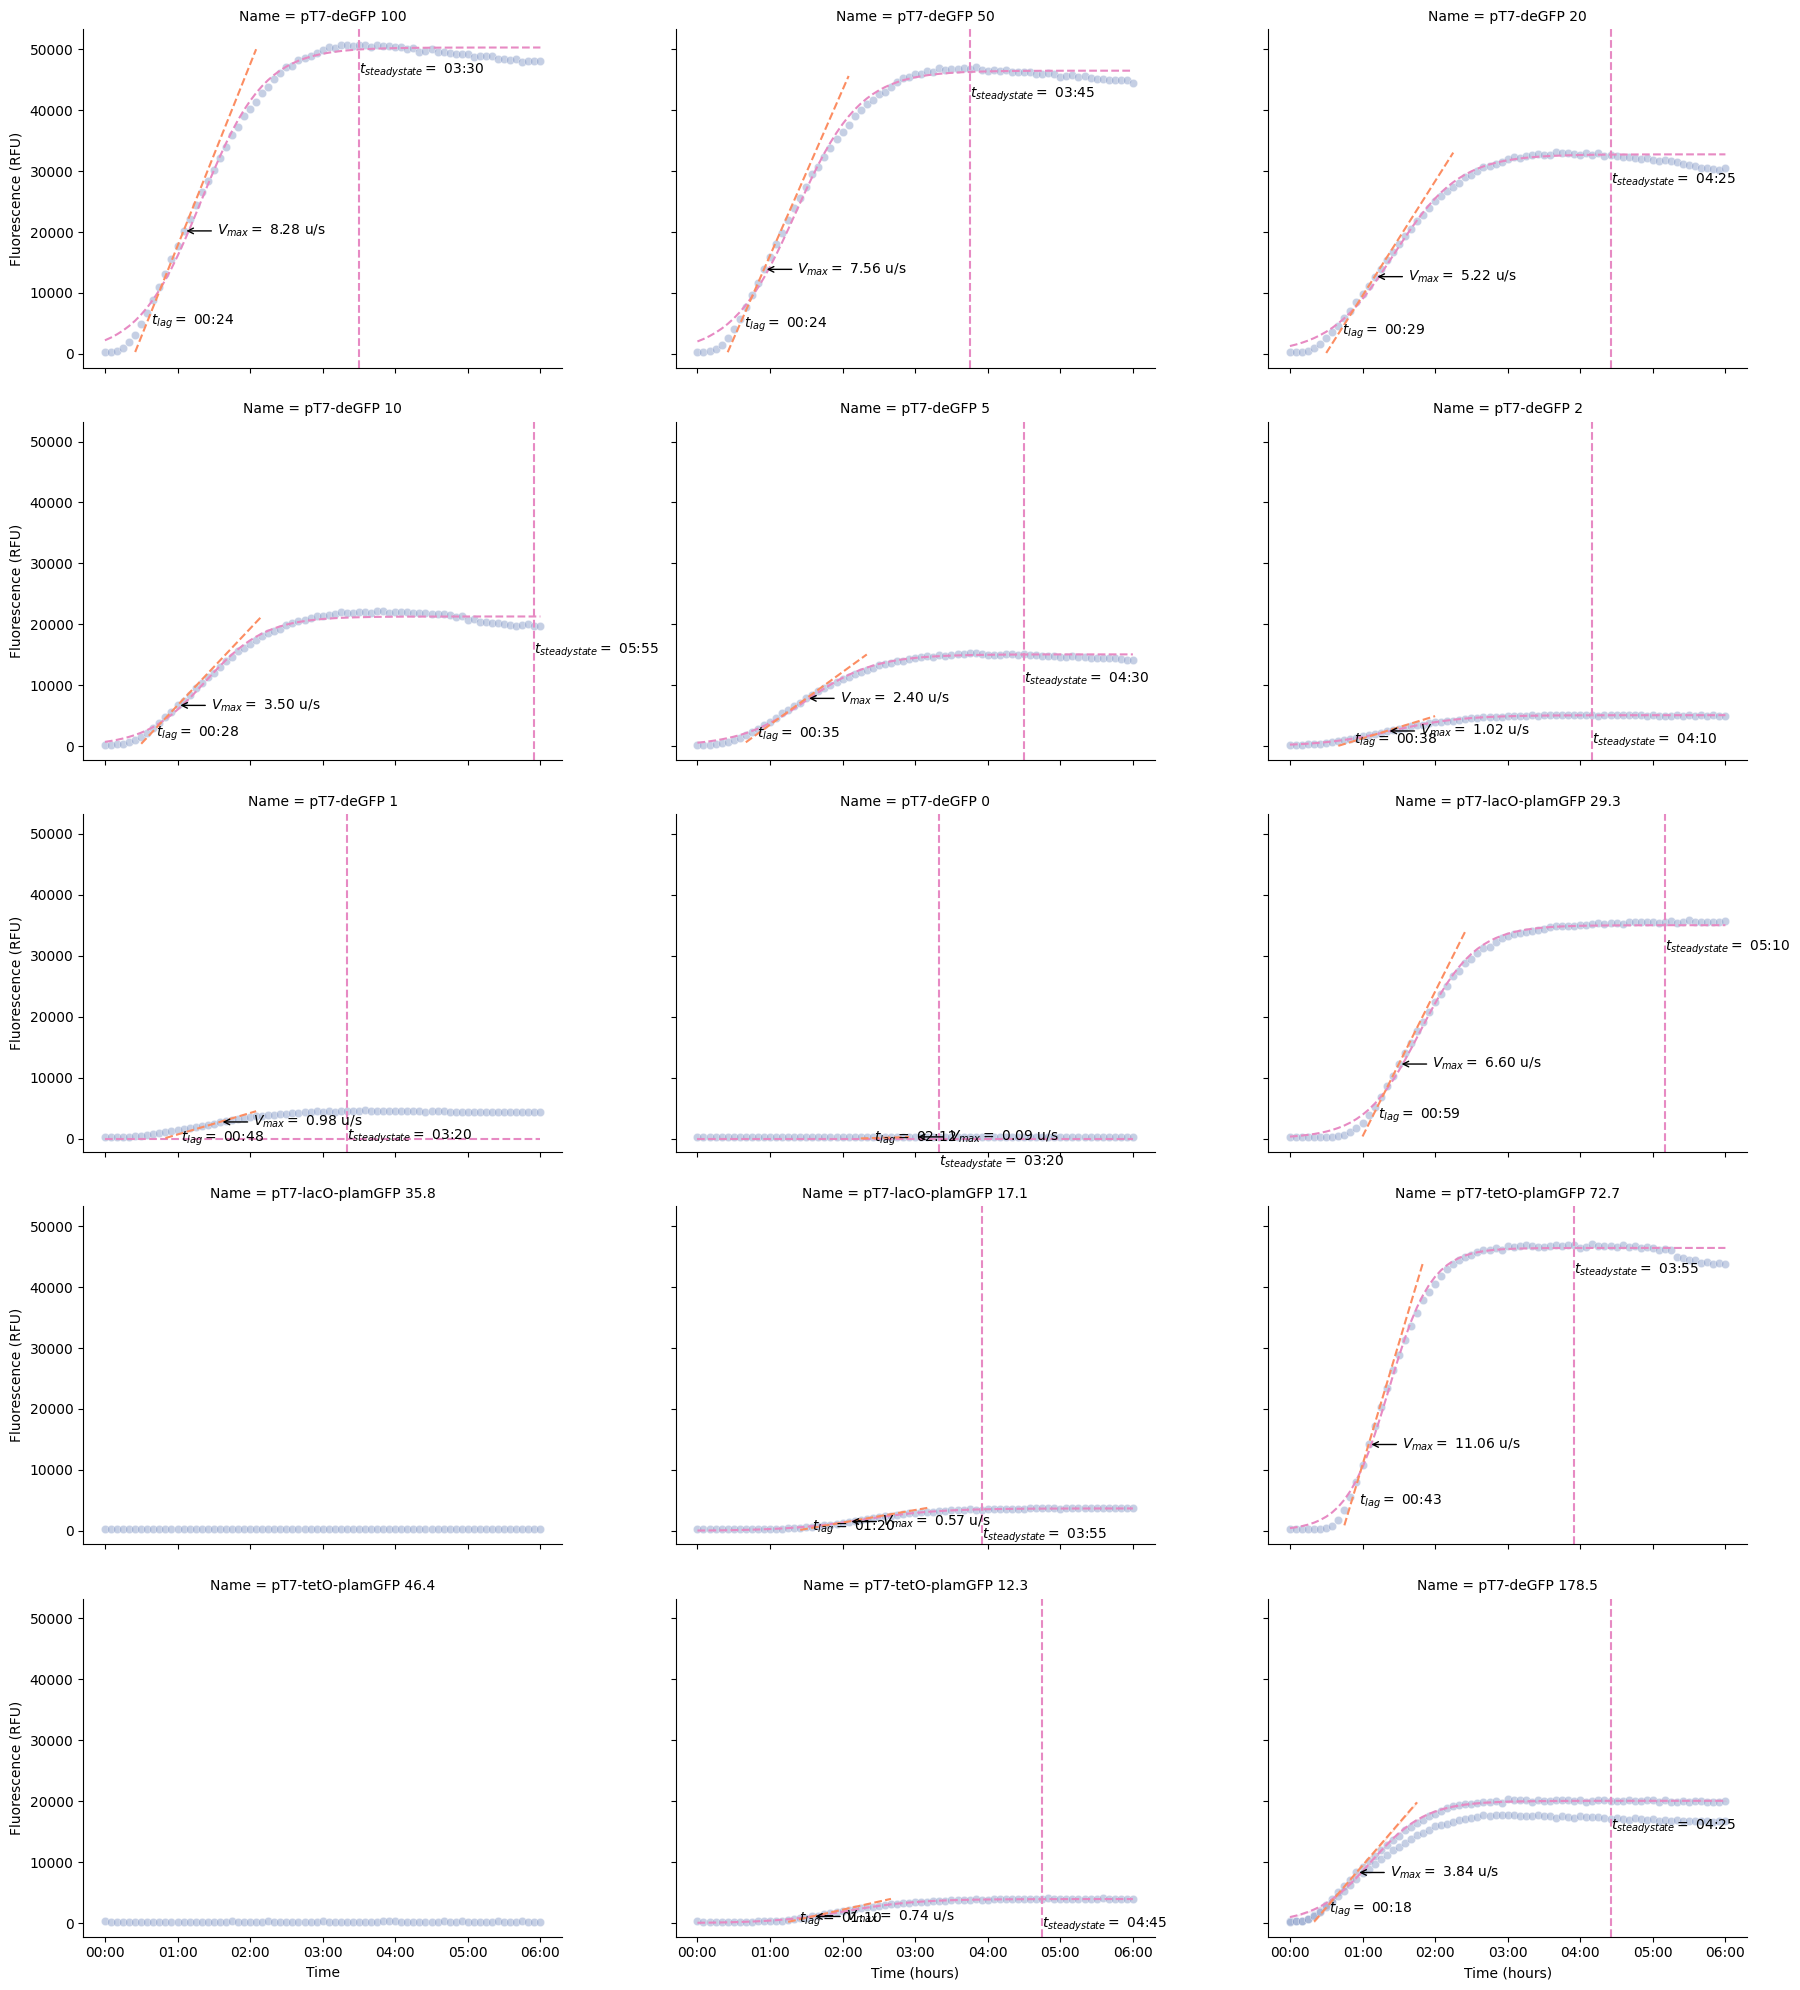

In [5]:
pr.plot_kinetics(data, kinetics, col_wrap=4)

# HVplot

In [11]:
data.hvplot(
    by=['[DNA Template] (ng/uL)'],
    groupby=['Experiment'],
    kind='line',
    logy=False,
    x='Time',
    y=['Data'],
    legend='bottom_right',
    widget_location='top',
    height=500,
    width=1000
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'d1b4562c-207c-486f-9fad-87dffaaa2504': {'version…

In [7]:
data.hvplot.explorer(x="Time", y="Data", by=["Name"], groupby=["Experiment"])

BokehModel(combine_events=True, render_bundle={'docs_json': {'29b4b1a6-625b-4805-879a-63b27d958eef': {'version…

UnknownReferenceError: can't resolve reference 'p3936'

UnknownReferenceError: can't resolve reference 'p3936'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

In [ ]:
exp.

'Well'